⚙️ Step 1: Setting up dataset configuration...
✅ Dataset automatically located at: /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset
✅ Configuration dynamically fixed and saved to: /kaggle/working/kaggle_visdrone.yaml

🚀 Step 2: Downloading YOLOv8 and starting training...
Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/kaggle_visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=

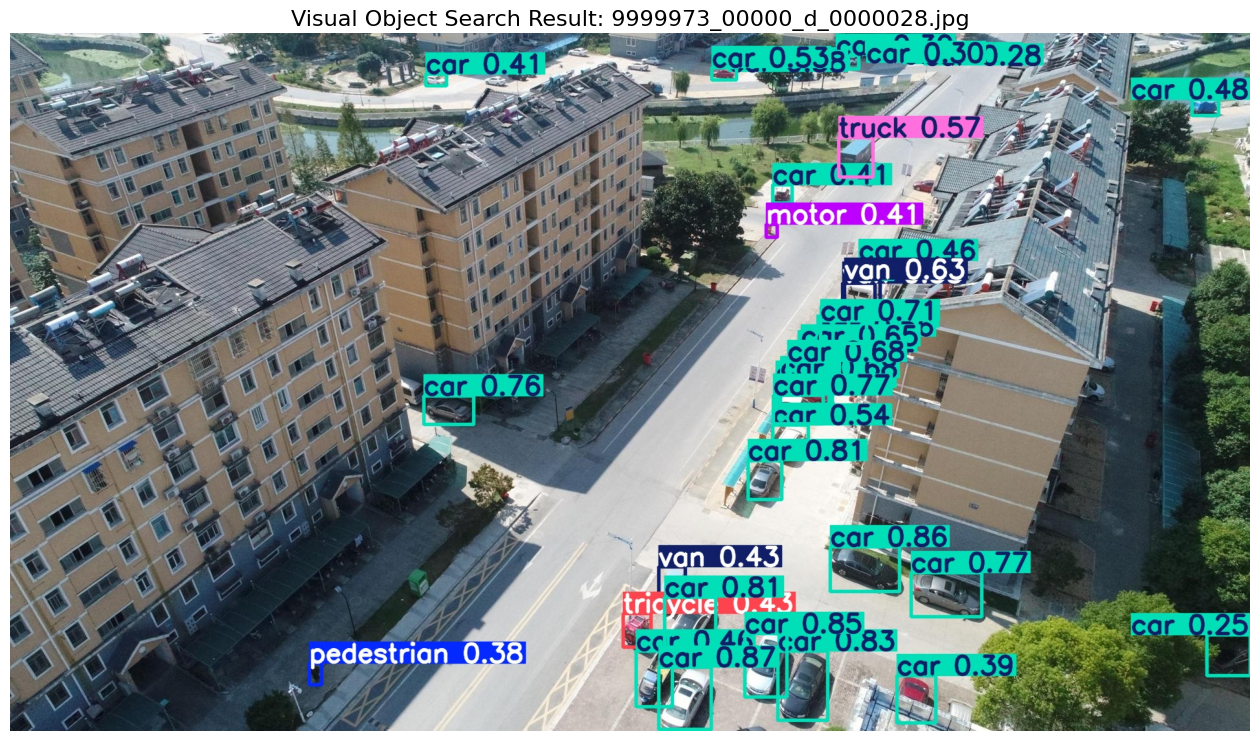

In [4]:


# 1. INSTALL DEPENDENCIES (Runs quietly in the background)
!pip install -q ultralytics

import os
import yaml
import cv2
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("⚙️ Step 1: Setting up dataset configuration...")
# 2. CONFIGURE DATASET PATHS DYNAMICALLY
# This searches your entire Kaggle input folder for the author's visdrone.yaml file
found_yamls = glob.glob('/kaggle/input/**/visdrone.yaml', recursive=True)

if not found_yamls:
    raise FileNotFoundError(" CRITICAL ERROR: Could not find 'visdrone.yaml'. Please check the right-side panel in Kaggle under 'Data' to ensure the VisDrone dataset is actively attached to this notebook.")

# Automatically extract the exact path where the file was found
original_yaml_path = found_yamls[0]
base_dataset_path = os.path.dirname(original_yaml_path)
working_yaml_path = '/kaggle/working/kaggle_visdrone.yaml'

print(f" Dataset automatically located at: {base_dataset_path}")

# Read the author's configuration
with open(original_yaml_path, 'r') as f:
    config_data = yaml.safe_load(f)

# Override the root path to point exactly to the dynamically found directory
config_data['path'] = base_dataset_path

# Save the fixed config to Kaggle's working directory so YOLO can read it
with open(working_yaml_path, 'w') as f:
    yaml.dump(config_data, f)

print(f" Configuration dynamically fixed and saved to: {working_yaml_path}")

print("\n🚀 Step 2: Downloading YOLOv8 and starting training...")
# 3. INITIALIZE AND TRAIN THE MODEL
model = YOLO('yolov8s.pt') # 's' stands for small (fastest for Kaggle GPUs)

# NOTE: epochs=10 is for a quick test run (~15 mins). 
# Change to 50+ for your final project presentation to get accurate detections!
results = model.train(
    data=working_yaml_path,
    epochs=10,        
    imgsz=640,       
    batch=16,        
    device=0,         # '0' forces it to use the Kaggle GPU
    project='/kaggle/working/Drone_Project',
    name='training_run'
)
print(" Training complete!")

print("\n Step 3: Running Visual Object Search on a test image...")
# 4. INFERENCE / VISUAL SEARCH
best_weights_path = '/kaggle/working/Drone_Project/training_run/weights/best.pt'

# Dynamically search for ANY .jpg file inside the test folder
test_images = glob.glob(f"{base_dataset_path}/**/VisDrone2019-DET-test-dev/**/*.jpg", recursive=True)

if not test_images:
    print(" Error: Could not find any .jpg images in the test folder to run a search on!")
else:
    target_test_image = test_images[0]
    image_filename = os.path.basename(target_test_image)

    # Load your newly trained custom drone model
    drone_model = YOLO(best_weights_path)

    # Run the prediction (confidence threshold set to 25%)
    prediction_results = drone_model.predict(
        source=target_test_image, 
        conf=0.25,        
        save=True,        
        project='/kaggle/working/Drone_Project',
        name='search_results'
    )

    print("\n Step 4: Displaying the result...")
    # 5. DISPLAY THE OUTPUT IMAGE IN THE NOTEBOOK
    output_image_path = os.path.join('/kaggle/working/Drone_Project/search_results', image_filename)

    if os.path.exists(output_image_path):
        img = cv2.imread(output_image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert from OpenCV BGR to standard RGB
        
        plt.figure(figsize=(16, 12))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"Visual Object Search Result: {image_filename}", fontsize=16)
        plt.show()
    else:
        print(" Error: The model ran, but could not find the saved output image to display.")

In [ ]:
# VISUAL OBJECT SEARCH IN DRONE IMAGES

!pip install -q ultralytics   # install YOLOv8 library

import os
import yaml
import cv2
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("Step 1: Dataset setup")

# Find visdrone.yaml automatically so code works on any Kaggle path
found_yamls = glob.glob('/kaggle/input/**/visdrone.yaml', recursive=True)
if not found_yamls:
    raise FileNotFoundError("visdrone.yaml not found. Attach dataset in Kaggle.")

original_yaml_path = found_yamls[0]
base_dataset_path = os.path.dirname(original_yaml_path)
working_yaml_path = '/kaggle/working/kaggle_visdrone.yaml'

# Load dataset config and update path so YOLO knows exact data location
with open(original_yaml_path, 'r') as f:
    config_data = yaml.safe_load(f)

config_data['path'] = base_dataset_path

# Save updated config because YOLO reads from this file during training
with open(working_yaml_path, 'w') as f:
    yaml.dump(config_data, f)

print("Dataset ready")

print("Step 2: Training model")

# Use yolov8m → better accuracy than small model (yolov8s)
model = YOLO('yolov8m.pt')

results = model.train(
    data=working_yaml_path,   # dataset config
    epochs=50,                # more epochs → better learning
    imgsz=640,               # standard size balancing speed & accuracy
    batch=8,                 # reduced to avoid GPU memory overflow
    device=0,                # use GPU for faster training
    project='/kaggle/working/Drone_Project',
    name='training_run'
)

print("Training complete")

print("Step 3: Running detection")

# Load best trained weights → model after learning
best_weights_path = '/kaggle/working/Drone_Project/training_run/weights/best.pt'
drone_model = YOLO(best_weights_path)

# Get test images to check model performance on unseen data
test_images = glob.glob(f"{base_dataset_path}/**/VisDrone2019-DET-test-dev/**/*.jpg", recursive=True)

if not test_images:
    print("No test images found")
else:
    target_test_image = test_images[0]   # pick one sample image
    image_filename = os.path.basename(target_test_image)

    # Run prediction → detect objects with confidence threshold
    drone_model.predict(
        source=target_test_image,
        conf=0.25,          # ignore very low confidence detections
        save=True,          # save output image with bounding boxes
        project='/kaggle/working/Drone_Project',
        name='search_results'
    )

    print("Step 4: Displaying result")

    # Path where YOLO saves detected image
    output_image_path = os.path.join('/kaggle/working/Drone_Project/search_results', image_filename)

    if os.path.exists(output_image_path):
        img = cv2.imread(output_image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Show final result with detected objects
        plt.figure(figsize=(12, 8))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title("Detected Objects")
        plt.show()
    else:
        print("Output image not found")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Step 1: Dataset setup
Dataset ready
Step 2: Training model
Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/kaggle_visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0